## Motivation (skip if you paid attention during the slides)

Quantum computers natively execute operations that are strictly reversible and unitary. However, we frequently encounter scenarios where we must implement non-unitary operators on quantum hardware. Common motivations include:

- Algorithmic Approximations: When simulating dynamics, expanding the exponential $e^{-iHt}$ (via Taylor series or Suzuki-Trotter expansions) and truncating it at a specific order leaves you with a non-unitary polynomial.

- Open Quantum Systems: When a quantum system interacts with an external environment, its effective Hamiltonian becomes non-Hermitian, meaning its evolution operator is no longer unitary.

- Linear Algebra Tasks: Algorithms that solve linear systems of equations require applying inherently non-unitary functions, such as matrix inversion ($A^{-1}$), directly to an operator.

We know that product between unitary operators 
($U^\dagger U=UU^\dagger = I$)
U and V is always unitary
$$(UV)(UV)^\dagger=UVV^\dagger U^\dagger = UIU^\dagger =UU^\dagger=I,$$
this does not always hold for addition $\sum_i U_i$.

We can, however, apply this linear combination of unitaries to a quantum state (action of $A$) using a technique called block encoding by placing a not necessarily unitary operator $A$ into a larger unitary matrix

$$U_A = 
\begin{pmatrix} 
 A/\alpha & * \\ 
 * & *
\end{pmatrix}.$$

Once block encoded, we can use Quantum Signal Processing (QSP) and its generalizations to manipulate the operator and apply arbitrary functional transformations.

The fine print to ke keep in mind for the rest of this notebook is the scaling factor $\alpha$. There is no free lunch: the embedding is exact, but recovering $A\ket{\psi}$ requires measuring the ancillas and hoping
for $\ket{0}$, which succeeds with probability $\|A\ket{\psi}\|^2/\alpha^2$.

## Goal of tutorial (skip if you paid attention during the slides)

The end goal of the tutorial is to be able to use block encodings as programming abstractions using Qrisp's ``BlockEncoding`` class.

An example all the things that are happening in the following code block:

In [2]:
import numpy as np
from qrisp import *
from qrisp.block_encodings import BlockEncoding

A = np.array([[ 0.66,  0.02, -0.11, -0.16],
    [ 0.02,  0.82,  0.01, -0.12],
    [-0.11,  0.01,  0.93, -0.07],
    [-0.16, -0.12, -0.07,  0.69]])

B = np.array([[ 0.78, -0.01, -0.16, -0.1 ],
    [-0.01,  0.57, -0.03,  0.08],
    [-0.16, -0.03,  0.69, -0.15],
    [-0.1 ,  0.08, -0.15,  0.88]])

b = np.array([1., 2., 1., 1.])

epsilon = 0.01
kappa = np.linalg.cond(B)

B_A = BlockEncoding.from_array(A)
B_B = BlockEncoding.from_array(B)

C = np.eye(4) + A - 2 * A @ A + np.linalg.inv(B) # NumPy

B_C = B_A.poly([1.,1.,-2.]) + B_B.inv(epsilon, kappa) # Qrisp

# Normalize for comparison to quantum solution.
c = C @ b / np.linalg.norm(C @ b)
print("numpy: ", c)
# numpy: [0.44707785 0.66049416 0.41341197 0.43927144]

# Prepare variable in state |b>
def prep_b(b):
    qv = QuantumFloat(2)
    prepare(qv, b)
    return qv

@terminal_sampling
def main(b):
    # Applies the Hermitian operator C to state |b>
    # using a repeat-until-success protocol.
    return B_C.apply_rus(prep_b)(b)

res_dict = main(b)

# Convert measurement probabilites to (absolute values of) amplitudes.
amps = np.sqrt([res_dict.get(i, 0) for i in range(len(b))])
print("qrisp:", amps)

# Resource Estimation
res_dict = B_C.resources(QuantumFloat(2))
print("Resource estimation:",res_dict)

numpy:  [0.44707785 0.66049416 0.41341197 0.43927144]
qrisp: [0.44423199 0.66648344 0.40569366 0.44030717]                            
Resource estimation: {'gate counts': {'gphase': 1116, 'h': 1622, 'p': 231, 's': 126, 'u3': 930, 's_dg': 6, 'x': 924, 'ry': 2, 'cy': 62, 'cz': 186, 't_dg': 2734, 't': 2112, 'cx': 5869, 'measure': 120}, 'depth': 7574, 'qubits': 18}


## Block encodings

### Formal definition (skip if you paid attention during the slides)

Following the standard definition (see [Lin Lin, Chapter 8](https://arxiv.org/pdf/2201.08309)), we say that a unitary $U$ is an $(\alpha, m, \epsilon)$-block-encoding of $A$ if
$$\| A - \alpha (\bra{G} \otimes I) U (\ket{G} \otimes I) \| \leq \epsilon,$$
Where:
- $\alpha$ (Scaling Factor): Since $\|U\|=1$, we must scale $A$ such that $\|A/\alpha\| \leq 1$. Usually, $\alpha$ is related to the 1-norm of the coefficients in an LCU decomposition.

- $m$ (Ancilla Qubits): The number of additional qubits required to define the larger Hilbert space in which $U$ acts.

- $\epsilon$ (Precision): The error tolerance. In practice, our quantum circuit $U$ only approximates $A$ to a certain degree of accuracy.

- $\ket{G}$ (Signal State): Often called the "ancilla state," this is a specific basis state (typically $\ket{0}^{\otimes m}$) that defines the subspace where $A$ is embedded.

If an operator $A$ is expressed as a weighted sum of unitaries ($A=\sum_i\alpha_i U_i$), the LCU algorithmic primitive uses three oracles:

- $\text{PREPARE}$ prepares a superposition of index states weighted by the square roots of the coefficients $\alpha_i$ in the ancillary variable:$$\text{PREP}\ket{0}_a=\sum_{i=0}^{m-1}\sqrt{\frac{\alpha_i}{\alpha}}\ket{i}_a$$

- $\text{SELECT}$ applies the corresponding unitary $U_i$ to the operand (target) variable, controlled by the ancillary variable:$$\text{SEL}=\sum_{i=0}^{m-1}\ket{i}\bra{i}_a\otimes U_i,$$

- and finally, $\text{PREPARE}^\dagger$, which then essentially "unprepares" the ancillary variable.

We have successfully applied $A$ to our operand when the ancillary variable is measured in the $\ket{0}$ state.

Final sanity check: $$\Big(\textstyle\sum_i \sqrt{\tfrac{\alpha_i}{\alpha}}\langle i|\Big)\Big(\textstyle\sum_j |j\rangle\langle j|\otimes U_j\Big)\Big(\textstyle\sum_k \sqrt{\tfrac{\alpha_k}{\alpha}}|k\rangle\Big)\;=\; \sum_i \tfrac{\alpha_i}{\alpha} U_i \;=\; A/\alpha$$

![title](images/BE_bad_select.png)

We could also define a block encoding as a pair of unitaries $(U, G)$ ($G$ is another name for PREPARE, $U$ is another name for SELECT). Their action on quantum states can be captured by the following expressions:

- $G$ simply prepares the auxiliary variable in a superposition defined by the coefficients (or the weights) of the weighted sum of unitaries (LCU):

$$G\ket{0}_{index}=\ket{G}_{index}.$$

Here, we've denoted the ancillary variable as ``index``.

- $U$, on the other hand then selects "just the right amount" of each of the underlying unitaries in the weighted sum: 

$$U\ket{i}_{index}\ket{\psi}_{operand}=\ket{i}_{index}U_i\ket{\psi}_{operand}.$$



### BlockEncoding constructors (Pay attention now)

The $\texttt{BlockEncoding}$ class provides several factory methods to instantiate block-encodings from various mathematical structures:

| Method | Purpose | Typical Use Case |
| :--- | :--- | :--- |
| .from_array(arr) | Encodes a NumPy matrix | Quick prototyping of small, specific matrices |
| .from_operator(op) | Encodes a Hamiltonian | Physics and Chemistry simulations |
| .from_lcu(coeffs, unitaries) | Custom weighted sum of unitaries | High-efficiency implementation |
| .from_eye(k) | Encodes a diagonal offset by $k$ | Constructing block encodings |
| .from_projector(L, R) | $\ket{\phi}\!\bra{\psi}$ | Custom state preparation |

#### $\texttt{from\_array(A)}$: 

Constructs a block-encoding directly from a 2-D numerical matrix $\hat{A}$.

In [3]:
import numpy as np
from qrisp.block_encodings import BlockEncoding
A = np.array([[0,1,0,1],[1,0,0,0],[0,0,1,0],[1,0,0,0]])
B_A = BlockEncoding.from_array(A)

#### $\texttt{from\_operator(O)}$: 
Constructs a block-encoding directly form quantum mechanical operators, i.e., Qrisp's $\texttt{QubitOperator}$ and $\texttt{FermionicOperator}$.

In [4]:
from qrisp.block_encodings import BlockEncoding
from qrisp.operators import X, Y, Z
O = X(0)*X(1) + 0.2*Y(0)*Y(1)
B = BlockEncoding.from_operator(O)

Fermionic operators go through the same machinery, with a Jordan–Wigner transformation inserted first:
`FermionicOperator` → `QubitOperator` → Pauli strings → LCU.

In [5]:
from qrisp.operators.fermionic import a, c

O = a(1)*c(2)+a(2)*c(1)+a(2)*c(3)+a(3)*c(2)
B = BlockEncoding.from_operator(O)

What is happening under the hood? We are decomposing the matrix (and the matrix representing the operator).

When you have multiple qubits, you take the tensor product of these matrices. For example, a Pauli string for a 3-qubit system might look like $X \otimes Z \otimes I$ (often shortened to $XZI$). If you can break an operator down into Pauli strings, a quantum computer knows exactly how to execute it.

$$A=\sum_i\alpha_iP_i$$

An example is the $n$-qubit Heisenberg Hamiltonian $$H=\sum_{i=0}^{n-1}(X_iX_{i+1}+Y_i Y_{i+1}+Z_iZ_{i+1})$$

And this is exactly what these methods do. The former takes an arbitrary square matrix and expresses it as a weighted sum of these Pauli strings ($A=\sum_j\alpha_j P_j$), where $\alpha_j$ is a scalar coefficient (aka a number) and $P_j$ is a Pauli string, while in the latter, we already provide the Hamiltonian in terms of these Pauli strings.

Alright, but how does that look in code? Well, for that there is the form_lcu constructor.

#### $\texttt{from\_lcu(coeffs, unitaries, \dots)}$: 
Utilizes the linear combination of unitaries protocol to encode $A = \sum_k \alpha_k U_k$.

Here is the matrix we will use for the rest of this section: the 1-D discrete Laplacian with periodic
boundary conditions,

$$\Delta = 2I - V - V^\dagger,\qquad V\ket{k}=-\ket{k+1 \bmod N} .$$

Three unitaries, at any $N$, and in Qrisp a cyclic shift is `qv += 1`.

In [6]:
import numpy as np

N = 8
I = np.eye(N)
L = 2 * I - np.eye(N, k=1) - np.eye(N, k=-1)
L[0, N-1] = -1
L[N-1, 0] = -1

print(L)

[[ 2. -1.  0.  0.  0.  0.  0. -1.]
 [-1.  2. -1.  0.  0.  0.  0.  0.]
 [ 0. -1.  2. -1.  0.  0.  0.  0.]
 [ 0.  0. -1.  2. -1.  0.  0.  0.]
 [ 0.  0.  0. -1.  2. -1.  0.  0.]
 [ 0.  0.  0.  0. -1.  2. -1.  0.]
 [ 0.  0.  0.  0.  0. -1.  2. -1.]
 [-1.  0.  0.  0.  0.  0. -1.  2.]]


In [7]:
from qrisp import gphase

def I(qv):
    # Identity: do nothing
    pass

def V(qv):
    # Forward cyclic shift with a global phase -1
    qv += 1
    gphase(np.pi, qv[0])  # multiply by -1

def V_dg(qv):
    # Backward cyclic shift with a global phase -1
    qv -= 1
    gphase(np.pi, qv[0])

unitaries = [I, V, V_dg]
coeffs = np.array([2.0, 1.0, 1.0])

BE = BlockEncoding.from_lcu(coeffs, unitaries)

But what is the difference between using ``.from_array``, ``.from_operator``, and ``.from_lcu``? Which one should the user use?

Well, while the Pauli decomposition is efficient for certain physical Hamiltonians (polynomial scaling of number of Pauli strings), it is inneficient for general (algorithmic matrices) with exponential scaling of number of Pauli strings.

In the case of the $n$-qubit discrete Laplacian (with periodic boundary conditions) above, the number of Pauli strings scales as $3\cdot2^{n-2}$ in $n$.  That is 96 terms at $N=128$, versus three terms for the LCU route, independent of $N$.

The Gidney adder implementing the shift operator $\ket{x}\rightarrow\ket{x+1\space\mod N}$ scales linearly in $n$.

The more terms in the block encoding, the more the cost of the algorithm. STRUCTURE MATTERS!

We can also compare the two alternatives using the...

## .resources() for easy resource estimation


In [8]:
BE_PD = BlockEncoding.from_array(np.array(L))

QRE_LCU = BE.resources(QuantumFloat(int(np.log2(N))))
QRE_PD = BE_PD.resources(QuantumFloat(int(np.log2(N))))

print("Resource estimation for LCU: ", QRE_LCU)
print("Resource estimation for PD: ", QRE_PD)

Resource estimation for LCU:  {'gate counts': {'gphase': 8, 'h': 16, 'p': 2, 's': 4, 'u3': 6, 'x': 5, 't_dg': 16, 't': 14, 'cx': 54, 'measure': 4}, 'depth': 51, 'qubits': 9}
Resource estimation for PD:  {'gate counts': {'gphase': 18, 'h': 14, 'p': 4, 'u3': 14, 'x': 9, 'cy': 4, 't_dg': 28, 't': 21, 'cx': 67}, 'depth': 103, 'qubits': 9}


Let's plot!

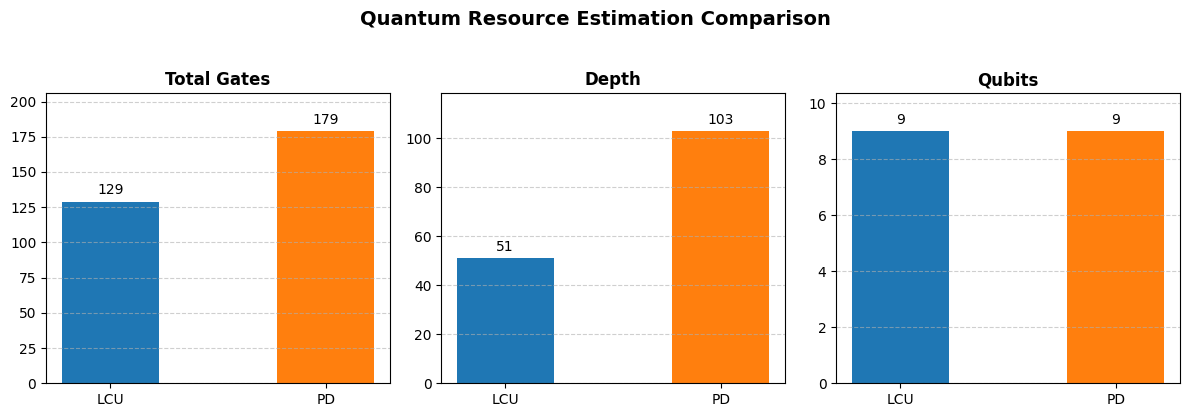

In [9]:
import matplotlib.pyplot as plt

def plot_resource_comparison(qre_lcu, qre_pd):
    # Extract metrics from dictionaries
    metrics_lcu = {
        'Total Gates': sum(qre_lcu['gate counts'].values()),
        'Depth': qre_lcu['depth'],
        'Qubits': qre_lcu['qubits']
    }
    
    metrics_pd = {
        'Total Gates': sum(qre_pd['gate counts'].values()),
        'Depth': qre_pd['depth'],
        'Qubits': qre_pd['qubits']
    }

    categories = list(metrics_lcu.keys())
    methods = ['LCU', 'PD']
    colors = ['#1f77b4', '#ff7f0e']

    # Create 1x3 subplot grid to handle scale differences cleanly
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    
    for idx, category in enumerate(categories):
        ax = axes[idx]
        values = [metrics_lcu[category], metrics_pd[category]]
        
        bars = ax.bar(methods, values, color=colors, width=0.45)
        ax.set_title(category, fontsize=12, fontweight='bold')
        ax.grid(axis='y', linestyle='--', alpha=0.6)
        
        # Expand y-limit slightly to make room for text annotations
        ax.set_ylim(0, max(values) * 1.15 if max(values) > 0 else 1)
        
        # Display exact values above each bar
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f'{height:,}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=10)

    plt.suptitle("Quantum Resource Estimation Comparison", fontsize=14, fontweight='bold', y=1.03)
    plt.tight_layout()
    plt.show()

# --- Example Usage ---
# Pass your dictionary variables directly into the function:
plot_resource_comparison(QRE_LCU, QRE_PD)

#### $\texttt{BlockEncoding(alpha, ancillas, unitary, \dots)}$: 
Initializes a custom block-encoding by explicitly defining the subnormalization factor $\alpha$, ancilla $\texttt{QuantumVariable}$ templates, and the $\texttt{unitary}$ function.

In [10]:
from qrisp import conjugate, prepare, q_switch, QuantumFloat
from qrisp.operators import X, Y

H = X(0)*X(1) + 0.2*Y(0)*Y(1)

# Returns a list of unitaries, i.e., functions performing in-place operations
# on the operand quantum variable, and a list of coefficients.
unitaries, coeffs = H.unitaries()
n = len(unitaries).bit_length() # Number of qubits for ancillary variable.
alpha = np.sum(coeffs) # Block encoding normalization factor.

# Define block-encoding unitary using LCU = PREP SELECT PREP_dg.
def U(anc, operand):
    with conjugate(prepare)(anc, coeffs):
        q_switch(anc, unitaries, operand) # quantum switch aka SELECT

BE = BlockEncoding(
    alpha,  # Block encoding normalization factor.
    [QuantumFloat(n)],  # Templates for ancilla variables.
    U,  # Block encoding unitary.
    num_ops=1,  # Number of operand variables. The default is 1.
    is_hermitian=True,  # Indicates whether the unitary is Hermitian.
)

As you'll see, this is also how the functions for QSP approaches look like!

| Method | Purpose | Typical Use Case |
| :--- | :--- | :--- |
| .resources(qv) | Estimates gate counts, depth, and qubits. | Resource analysis and benchmarking |
| .apply(qv) | Applies a matrix to a quantum state | NISQ hardware with manual post-selection |
| .apply_rus(prep_func) | Applies a matrix to a quantum state | Fault-tolerant / Repeat-Until-Success logic |
| `.expectation_value(prep, ...)` | $\bra{\psi}A\ket{\psi}$ via a Hadamard test and never post-selects | When you only want a number (ground state energy) |
| ``+``, ``-``, ``*``, ``@``, ``.kron()`` | Algebraic arithmetic on encodings | Constructing complex composite systems |

### Applying the block encoding to a state with [.apply_rus](../../../reference/Block%20Encodings/methods/apply_rus.rst)

Tthe [.apply_rus](../../../reference/Block%20Encodings/methods/apply_rus.rst) method wraps the entire process into a loop:

- It prepares your input state.
- It applies the block encoding.
- It measures the ancillas.
- If the ancillas are not zero, it resets them and starts over automatically.
- If they are zero, it stops. You now have the exact state you wanted. If not, the loop repeats again.

The cost of a
loose $\alpha$ shows up directly as more iterations.

In [12]:
from qrisp import *
from qrisp.block_encodings import BlockEncoding
from qrisp.operators import X, Y, Z

H = sum(X(i)*X(i+1) + Y(i)*Y(i+1) + Z(i)*Z(i+1) for i in range(3))
BE = BlockEncoding.from_operator(H)
b = np.array([1.,2.,3.,1.,1.,2.,3.,1.,1.,2.,3.,1.,1.,2.,3.,1.])

# Prepare initial system state
def operand_prep():
    operand = QuantumFloat(4)
    
    prepare(operand, b)
    return operand

# Apply the operator to an initial system state
@terminal_sampling
def main():
    return BE.apply_rus(operand_prep)()
res_dict = main()

amps = np.sqrt([res_dict.get(i,0) for i in range(16)])
print(amps)
H_arr = H.to_array()

psi = H_arr @ b
psi = psi / np.linalg.norm(psi)
print(psi)
print(np.linalg.norm(psi-amps))

Simulating 4 qubits.. |                                                 | [  0%]

[0.13416408 0.35777086 0.13416408 0.22360678 0.3130495  0.26832819              
 0.3130495  0.13416408 0.13416408 0.35777092 0.13416408 0.22360678
 0.3130495  0.26832819 0.3130495  0.13416408]
[0.13416408+0.j 0.35777088+0.j 0.13416408+0.j 0.2236068 +0.j
 0.31304952+0.j 0.26832816+0.j 0.31304952+0.j 0.13416408+0.j
 0.13416408+0.j 0.35777088+0.j 0.13416408+0.j 0.2236068 +0.j
 0.31304952+0.j 0.26832816+0.j 0.31304952+0.j 0.13416408+0.j]
8.20081062725225e-08


In [13]:
def create_ising_hamiltonian(L, J, B):
    return sum(-J * Z(i) * Z(i + 1) for i in range(L-1)) + \
           sum(B * X(i) for i in range(L))

L = 4
H = create_ising_hamiltonian(L, 0.25, 0.5)
BE = BlockEncoding.from_operator(H)

def operand_prep(L):
    operand = QuantumFloat(L)
    b = np.array([1.,2.,3.,1.,1.,2.,3.,1.,1.,2.,3.,1.,1.,2.,3.,1.])
    prepare(operand, b)
    return operand

@terminal_sampling
def main(L):
    return BE.apply_rus(operand_prep)(L)

res_dict = main(L)
amps = np.sqrt([res_dict.get(i, 0) for i in range(2**L)])
print(amps)

H_arr = H.to_array()
b = np.array([1.,2.,3.,1.,1.,2.,3.,1.,1.,2.,3.,1.,1.,2.,3.,1.])
psi = H_arr @ b
psi = psi / np.linalg.norm(psi)
print(psi)
print(np.linalg.norm(psi-amps))

Simulating 4 qubits.. |                                                 | [  0%]

[0.1808389  0.16439898 0.31235808 0.21371867 0.24659848 0.29591816              
 0.31235808 0.21371867 0.21371867 0.23015856 0.41099751 0.24659848
 0.21371867 0.23015856 0.21371868 0.1808389 ]
[0.18083889+0.j 0.16439899+0.j 0.31235808+0.j 0.21371868+0.j
 0.24659848+0.j 0.29591818+0.j 0.31235808+0.j 0.21371868+0.j
 0.21371868+0.j 0.23015858+0.j 0.41099747+0.j 0.24659848+0.j
 0.21371868+0.j 0.23015858+0.j 0.21371868+0.j 0.18083889+0.j]
6.21213822921832e-08


#### Arithmetics
The algebra is sound, but it is not free, and the bookkeeping is all in $\alpha$ and the ancilla count:

| Operation | Meaning | Cost |
|:---|:---|:---|
| `BE1 + BE2` | $A+B$ | one extra selector qubit; $\alpha_1+\alpha_2$; **both** operands' ancillas stay alive |
| `BE1 - BE2` | $A-B$ | as above, plus a sign flip |
| `c * BE` | $cA$ | free — rescales $\alpha$ |
| `BE1 @ BE2` | $A\cdot B$ | ancillas add; $\alpha$ multiplies |
| `BE1.kron(BE2)` | $A\otimes B$ | ancillas add; $\alpha$ multiplies |
| `BE.dagger()` | $A^\dagger$ | free |

In [14]:
# Define two simple 2x2 matrices
A = np.array([[1, 0], [0, -1]]) # Pauli Z
B = np.array([[0, 1], [1, 0]])  # Pauli X

# Construct initial block-encodings
BA = BlockEncoding.from_array(A)
BB = BlockEncoding.from_array(B)

# 1. Addition and Subtraction (LCU-based)
B_add = BA + BB
B_sub = BA - BB

# 2. Scalar Multiplication and Negation
B_scaled = 2.5 * BA
B_neg = -BA

# 3. Matrix Multiplication
B_mult = BA @ BB

# 4. Tensor Product (Kronecker Product)
B_kron = BA.kron(BB)

## Qubitization, Chebyshev polynomials, Quantum Signal Processing (skip if you paid attention during the slides)

We want to compute functions of that matrix; like $e^{-iAt}$ for simulating dynamics (Hamiltonians), or $A^{-1}$ for solving linear systems, or even applying step functions or Gaussian functions as a filter for ground-state preparation. 

Classically we would approximate such an $f$ by a polynomial. Either a truncated Taylor or, much better on a
bounded interval, a truncated Chebyshev series

$$f(x)\;\approx\;\tilde f(x)\;=\;\sum_{k=0}^{d}c_k\,T_k(x),\qquad x\in[-1,1],$$

and then evaluate that polynomial at the matrix,

$$f(A)\;\approx\;\tilde f(A)\;=\;\sum_{k=0}^{d}c_k\,T_k(A)
\qquad\text{(meaning } \textstyle\sum_i \tilde f(\lambda_i)\ket{\lambda_i}\bra{\lambda_i}\text{ for Hermitian }A).$$

So the whole problem reduces to: given a block encoding of $A$, how do I build a block encoding of
$T_k(A)$?

While a block-encoding provides a ``static'' representation of an operator $A$, qubitization is a technique that transforms this encoding into a unitary quantum walk operator $\mathcal W$. For a Hermitian operator $A$, this walk operator encodes the eigenvalues of the normalized operator $A$ into its rotational phases, enabling transformations of the spectrum.

## Qubitization, Chebyshev polynomials, Quantum Signal Processing (skip if you paid attention during the slides)

We want functions of the encoded matrix: $e^{-iAt}$ to simulate dynamics, $A^{-1}$ to solve linear
systems, a step or Gaussian function to filter out everything but a ground state.

Classically we would approximate such an $f$ by a polynomial, a truncated Taylor or, much better on a
bounded interval, a truncated Chebyshev series

$$f(x)\;\approx\;\tilde f(x)\;=\;\sum_{k=0}^{d}c_k\,T_k(x),\qquad x\in[-1,1],$$

and then evaluate that polynomial at the matrix,

$$f(A)\;\approx\;\tilde f(A)\;=\;\sum_{k=0}^{d}c_k\,T_k(A)
\qquad\text{(meaning } \textstyle\sum_i \tilde f(\lambda_i)\ket{\lambda_i}\bra{\lambda_i}\text{ for Hermitian }A).$$

So the whole problem reduces to: given a block encoding of $A$, how do I build a block encoding of
$T_k(A)$?

### The obvious answer is wrong

Powers of a block encoding are not block encodings of powers. Writing $U_A$ in blocks,

$$U_A^2=\begin{pmatrix} A/\alpha & B\\ C & D\end{pmatrix}^2
      =\begin{pmatrix} A^2/\alpha^2+\mathbf{BC} & *\\ *&*\end{pmatrix}.$$

### Qubitization

Fix it with one reflection about the flagged ancilla state, interleaved between applications:

$$R=\big(2\ket{0}_a\!\bra{0}_a - I_a\big)\otimes I_s,\qquad\qquad \;W = R\cdot U_A\$$

$R$ does nothing to the good subspace and flips the sign of everything else, so on the next application
the leaked amplitude cancels instead of accumulating.

$W$ is called the qubitized walk operator, and it breaks the whole
Hilbert space into two-dimensional invariant subspaces, one per eigenvalue of $A$, and inside each it
acts as a single-qubit rotation by the angle $\theta_\lambda=\arccos(\lambda/\alpha)$. Hence the name
qubitization. Consequently

$$W^k \text{ block-encodes } T_k(A/\alpha)$$

with the same $\alpha$, the same ancillas, and $k$ applications of $U_A$. Degree is linear in depth
and free in width.


| Method | Purpose | Mathematical Basis |
| :--- | :--- | :--- |
| `.qubitization()` | applies a single layer of the qubitization walk operator $W$ | qubitization |
| `.chebyshev(k)` | applies a single Chebyshev polynomial $T_k(A)$ | qubitization |
| .poly(coeffs) | Applies an arbitrary polynomial transformation $P(A)$ | GQSP, GQET|
| .inv(eps, kappa) | Solves the [linear system](https://arxiv.org/pdf/2411.02522) $Ax = b$ | GQSP, QSVT, $1/x$ Chebyshev approximation |
| .sim(t, N)| Simulates Hamiltonian evolution $e^{-iHt}$ | GQSP, Jacobi-Anger expansion (Bessel functions) |

### Why $W^k$ block-encodes $T_k(A/\alpha)$

Worth writing out once, because it is the load-bearing fact of the second half and it takes half a page.
Let $A=\sum_i\lambda_i\ket{\lambda_i}\!\bra{\lambda_i}$ be Hermitian and write $\tilde\lambda=\lambda/\alpha
\in[-1,1]$.

Step 1: a 2-D invariant subspace per eigenvalue. Put $\ket{\phi_1}=\ket{0}_a\ket{\lambda}$.
By the block-encoding property and the fact that $U_A$ preserves norm,

$$U_A\ket{\phi_1}=\tilde\lambda\,\ket{\phi_1}+\sqrt{1-\tilde\lambda^2}\,\ket{\perp_\lambda},
\qquad \ket{\perp_\lambda}:=\frac{\big(U_A-\tilde\lambda\big)\ket{\phi_1}}{\sqrt{1-\tilde\lambda^2}},$$

a unit vector with no $\ket{0}_a$ component. For Hermitian $U_A$ one checks that
$\mathcal S_\lambda=\operatorname{span}\{\ket{\phi_1},\ket{\perp_\lambda}\}$ is invariant under both
$U_A$ and $R$, hence under $W=RU_A$.

Step 2: $W$ is a rotation there. In the ordered basis $\{\ket{\phi_1},\ket{\perp_\lambda}\}$,
$R$ acts as $\mathrm{diag}(1,-1)$, $\det W|_{\mathcal S_\lambda}=+1$, and

$$W\big|_{\mathcal S_\lambda}=
\begin{pmatrix}\tilde\lambda & \sqrt{1-\tilde\lambda^2}\\[2pt]
-\sqrt{1-\tilde\lambda^2} & \tilde\lambda\end{pmatrix}
= e^{+i\arccos(\tilde\lambda)\,Y},$$

a rotation by $\theta_\lambda=\arccos\tilde\lambda$.

Step 3: powers rotate by multiples of the angle.

$$W^k\big|_{\mathcal S_\lambda}=e^{ik\theta_\lambda Y}
\;\Longrightarrow\;
\bra{\phi_1}W^k\ket{\phi_1}=\cos(k\theta_\lambda)=\cos\big(k\arccos\tilde\lambda\big)
= T_k(\tilde\lambda),$$

the last equality being the definition of the Chebyshev polynomial of the first kind. Collecting all
eigenvalues,

$$\big(\bra{0}_a\otimes I\big)\,W^k\,\big(\ket{0}_a\otimes I\big)=\sum_i T_k(\tilde\lambda_i)\ket{\lambda_i}\!\bra{\lambda_i}=T_k(A/\alpha).\qquad\blacksquare$$


## Polynomial transformations using .poly()

In Qrisp, the [BlockEncoding class](../../../reference/Block%20Encodings/BlockEncoding.rst) provides the [.poly(coeffs)](../../../reference/Block%20Encodings/methods/poly.rst) method, which leverages GQET to apply a transformation $p(A)$ to a Hermitian matrix. You simply provide the coefficients, and Qrisp’s internal "autopilot" handles the phase solving and circuit construction.

Coefficients are lowest degree first, and `kind="Polynomial"` or `kind="Chebyshev"` selects the basis. Use `"Chebyshev"` whenever they came from a fit, since that is the basis qubitization natively speaks.

Example: Applying a custom polynomial. This example applies $p(A) = 1 + 2A + A^2$ to a matrix $A$ and applies the result to a vector $\ket{b}$.

In [15]:
import numpy as np
from qrisp import *
from qrisp.block_encodings import BlockEncoding

# Define a Hermitian matrix A and a vector b
A = np.array([[0.73255474, 0.14516978, -0.14510851, -0.0391581],
              [0.14516978, 0.68701415, -0.04929867, -0.00999921],
              [-0.14510851, -0.04929867, 0.76587818, -0.03420339],
              [-0.0391581, -0.00999921, -0.03420339, 0.58862043]])
b = np.array([0, 1, 1, 1])

# Generate a block-encoding and apply the polynomial [1, 2, 1]
BA = BlockEncoding.from_array(A)
BA_poly = BA.poly(np.array([1., 2., 1.]))

# Prepare the state |b>
def prep_b():
    operand = QuantumVariable(2)
    prepare(operand, b)
    return operand

@terminal_sampling
def main():
    # Use Repeat-Until-Success (RUS) to apply the non-unitary polynomial
    operand = BA_poly.apply_rus(prep_b)()
    return operand

res_dict = main()
amps = np.sqrt([res_dict.get(i, 0) for i in range(len(b))])

# Classical verification
c = (np.eye(4) + 2 * A + A @ A) @ b
c = c / np.linalg.norm(c)
print("QUANTUM SIMULATION\n", amps, "\nCLASSICAL SOLUTION\n", c)

QUANTUM SIMULATION                                                              
 [0.02986322 0.57992482 0.6241675  0.52269525] 
CLASSICAL SOLUTION
 [-0.02986321  0.57992485  0.6241675   0.52269522]


## Inversion using .inv & other quantum linear solvers

To apply the inverse matrix $A^{-1}$, we simply need to invert these eigenvalues:
$$A^{-1} = \sum_j \lambda_j^{-1} \ket{u_j}\bra{u_j}$$
Therefore, the challenge of finding a quantum operator that applies a matrix inverse boils down to applying the scalar function $f(x) = 1/x$ to the eigenvalues of $A$.

Because quantum circuits can efficiently implement polynomial transformations, the CKS algorithm achieves this by approximating the function $f(x) = 1/x$ using a linear combination of Chebyshev polynomials. Assuming the matrix $A$ is scaled so that its eigenvalues fall within the domain $D_{\kappa} = [-1, -1/\kappa] \cup [1/\kappa, 1]$ (where $\kappa$ is the condition number), the approximation is targeted precisely over this region. 

The algorithm constructs a block-encoding of the inverse operator:
$$A^{-1} \propto \sum_{j=0}^{j_0} \alpha_{2j+1} T_{2j+1}(A),$$
where $\alpha_j$ are carefully calculated coefficients. The more the terms, the better the approximation, as seen above, where the truncation order $j_0$ is mentioned next to the corresponding precision $\epsilon$.

$\epsilon$ here is (as already mentioned) the precision, with $\kappa$ being the condition number. The higher the $\kappa$, the more difficult is to solve the linear system. The higher the $\epsilon$, the more terms in the Chebyshev approximation, resulting in costing more resources.

Time for an example. In Qrisp, the ``.inv(eps, kappa)`` function takes a Block Encoding of matrix $A$ and returns a new Block Encoding representing $A^{-1}$. You can then apply this inverted operator to your state $\ket{b}$ using the Repeat-Until-Success (RUS) protocol. Here is how to solve a 4x4 Hermitian system:

In [16]:
import numpy as np
from qrisp import prepare, QuantumFloat
from qrisp.algorithms.cks import CKS
from qrisp.block_encodings import BlockEncoding
from qrisp.jasp import terminal_sampling

# 1. Define the linear system Ax = b
A = np.array([[0.73255474, 0.14516978, -0.14510851, -0.0391581],
              [0.14516978, 0.68701415, -0.04929867, -0.00999921],
              [-0.14510851, -0.04929867, 0.76587818, -0.03420339],
              [-0.0391581, -0.00999921, -0.03420339, 0.58862043]])

b = np.array([0, 1, 1, 1])

# Calculate condition number (needed for the polynomial approximation domain)
kappa = np.linalg.cond(A)

# 2. Define state preparation for vector |b>
def prep_b():
    operand = QuantumFloat(2)
    prepare(operand, b)
    return operand

@terminal_sampling
def main():
    # Convert matrix A to a Block Encoding
    BA = BlockEncoding.from_array(A)
    
    # Create the Block Encoding for A^-1 using CKS
    # This internally calculates coefficients and builds the LCU circuit
    BA_inv = BlockEncoding.inv(BA, eps=0.01, kappa=kappa)
    
    # Apply A^-1 to |b> using Repeat-Until-Success
    x = BA_inv.apply_rus(prep_b)()
    return x

# 3. Execute and compare results
res_dict = main()

# Extract amplitudes
amps = np.sqrt([res_dict.get(i, 0) for i in range(len(b))])
print("QUANTUM SIMULATION\n", amps)

# Calculate classical solution for verification
c = (np.linalg.inv(A) @ b) / np.linalg.norm(np.linalg.inv(A) @ b)
print("CLASSICAL SOLUTION\n", c)

QUANTUM SIMULATION                                                              
 [0.02711775 0.55708754 0.53034867 0.63847348]
CLASSICAL SOLUTION
 [0.02944539 0.55423278 0.53013239 0.64102936]


Resource estimation for different approaches? INtroduce CKS?

# Eigenstate filtering using quantum signal processing

Ground state preparation is a fundamental task in quantum computation, serving as a cornerstone for simulating strongly correlated systems in chemistry, material sciences and physics.

Understanding the ground state, i.e., the state of lowest energy, is essential for predicting a system's stability, electronic properties, and chemical reactivity.

However, finding the ground state is a notoriously difficult challenge. In fact, ground state preparation is QMA-complete, meaning it is generally hard even for quantum computers to find the exact solution for any arbitrary Hamiltonian. In practice, we often circumvent this complexity by starting with a 'good enough' initial guess (a trial state) and employing quantum algorithmsto systematically lower the system's energy, a process often referred to as algorithmic cooling.

Let us consider an $L$-qubit antiferromagnetic Heisenberg model

$$ H = \sum_{i=0}^{L-1}(X_iX_{i+1} + Y_iY_{i+1} + Z_iZ_{i+1}) $$

Physically, [antiferromagnetism](https://en.wikipedia.org/wiki/Antiferromagnetism) describes materials where neighboring spins "want" to point in opposite directions $\uparrow\downarrow$ to reach the lowest energy state. Unlike a standard fridge magnet (where spins point the same way), an antiferromagnet has no net external magnetism. These models are crucial for understanding quantum materials, such as high-temperature superconductors.

As initial system state we choose a tensor product of Singlet states

$$ \ket{\text{Singlet}} = 2^{-L/4}(\ket{10}-\ket{01})^{\otimes L/2} $$

of consecutive qubits. Starting at our initial state $\ket{\text{Singlet}}$, we aim to prepare a state with an even higher overlap with the ground state of the operator $H$

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
from qrisp import *
from qrisp.gqsp import GQSP
from qrisp.operators import X, Y, Z
from qrisp.vqe.problems.heisenberg import create_heisenberg_init_function


def generate_1D_chain_graph(L):
    graph = nx.Graph()
    graph.add_edges_from([(k, (k+1)%L) for k in range(L-1)])
    return graph


# Define Heisenberg Hamiltonian with spectrum in [-1,1].
L = 10
G = generate_1D_chain_graph(L)
H = (1 / (3 * L - 3)) * sum((X(i) * X(j) + Y(i) * Y(j) + Z(i) * Z(j)) \
                            for i, j in G.edges())

# Finds a maximum matching M of the graph G.
# For a chain graph G, M contains every second edge of G.
M = nx.maximal_matching(G)
# Prepares a tensor product of Singlet states 
# corresponding to the edges in M when applied to 
# a QuantumVariable in state |0>.
U0 = create_heisenberg_init_function(M)


# Define initial state preparation function
# preparing a tensor product of Singlet states.
def psi_prep():
    operand = QuantumVariable(L)
    U0(operand)
    return operand


# Calculate the energy for the initial state.
# Computes the operator's expectation value using Pauli measurement settings.
E = H.expectation_value(psi_prep, precision=0.001)()
print(E)

-0.556414414414415                                                              


Starting at our initial state $\ket{\psi_0}$, we aim to prepare a state with an even higher overlap with the ground state $\ket{\lambda_0}$. 
Therefore, we aim to apply a [Gaussian filter](https://en.wikipedia.org/wiki/Gaussian_filter) centered at $\lambda_0$ which suppresses higher energy components: indeed for 

$$ H = \sum_i\lambda_i\ket{\lambda_i}\bra{\lambda_i}\quad \text{and}\quad \ket{\psi_0} = \sum_i\alpha_i\ket{\lambda_i} $$

the state $\ket{\psi}$ after applying the filter $f$ is

$$ \ket{\psi} = \frac{f(H)\ket{\psi_0}}{\|f(H)\ket{\psi_0}\|} $$

where

$$ f(H)\ket{\psi_0} = \left(\sum_i f(\lambda_i)\ket{\lambda_i}\bra{\lambda_i}\right) \sum_j\alpha_j\ket{\lambda_j} = \sum_i f(\lambda_i)\alpha_i\ket{\lambda_i} $$

Thus, the magnitude of the amplitude of $\ket{\lambda_i}$ for $i>0$ is suppressed relative to the amplitude of $\ket{\lambda_0}$ in the state $\ket{\psi}$.

This filter is approximated by [Chebyshev polynomials](https://en.wikipedia.org/wiki/Chebyshev_polynomials) of the first kind. 

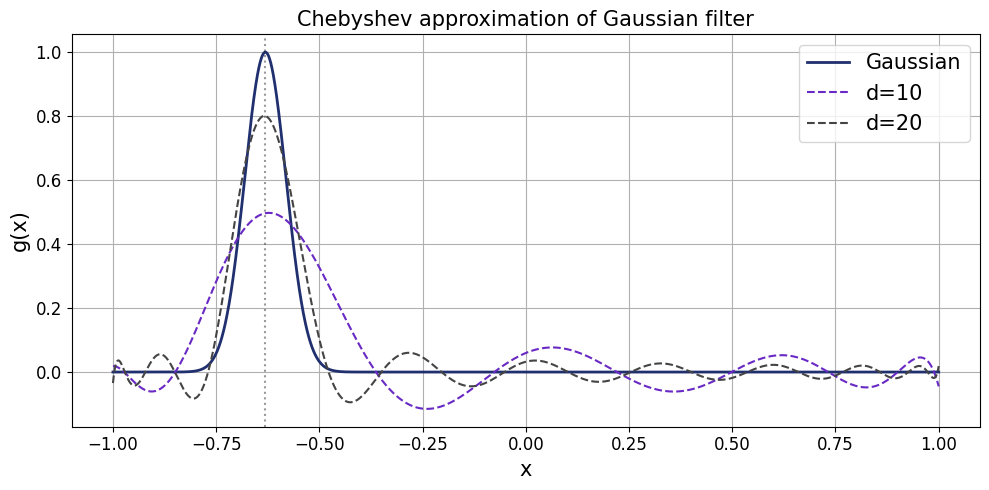

In [18]:
from numpy.polynomial import Chebyshev
from numpy.polynomial.chebyshev import chebval

# Define the Gaussian centered at minimal eigenvalue lambda_0 on [-1, 1].
H_matrix = H.to_array()
eigvals, eigvecs = np.linalg.eigh(H_matrix)

idx = np.argsort(eigvals)
eigvals_sorted = eigvals[idx].real

mu = eigvals_sorted[0]
sigma = 0.05

def gaussian(x):
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2)

# Chebyshev fit
x_nodes = np.cos(np.pi * np.arange(201) / 200)
f_nodes = gaussian(x_nodes)
cheb_fit = Chebyshev.fit(x_nodes, f_nodes, deg=100)
cheb_coeffs = cheb_fit.coef

x_plot = np.linspace(-1, 1, 2000)
f_gaussian = gaussian(x_plot)
f_cheb_10 = chebval(x_plot, cheb_coeffs[:11]) 
f_cheb_20 = chebval(x_plot, cheb_coeffs[:21])  

# Plot
plt.figure(figsize=(10, 5))
plt.plot(x_plot, f_gaussian, color='#20306f', label='Gaussian', linewidth=2)
plt.plot(x_plot, f_cheb_10, color='#6929C4', label='d=10', linestyle='--')
plt.plot(x_plot, f_cheb_20, color='#444444', label='d=20', linestyle='--')
plt.axvline(mu, color='k', linestyle=':', alpha=0.4)
plt.xlabel('x', fontsize=15)
plt.xticks(fontsize=12)
plt.ylabel('g(x)', fontsize=15)
plt.yticks(fontsize=12)
plt.title('Chebyshev approximation of Gaussian filter', fontsize=15)
plt.legend(fontsize=15)
plt.grid()
plt.tight_layout()
plt.show()

In [19]:
from qrisp.block_encodings import BlockEncoding

# Encodes the operator $H$.
BE = BlockEncoding.from_operator(H)

# Encodes the operator p(H) for a degree 10 Chebychev approximation 
# of the Gaussian filter.
BE_filter = BE.poly(cheb_coeffs[:11], kind="Chebyshev") 

# Returns the filtered state.
def filtered_psi_prep():
    # Applies p(H) to the inital state |psi_0>.
    operand = BE_filter.apply_rus(psi_prep)()
    return operand

@jaspify(terminal_sampling=True)
def main(): 

    E = H.expectation_value(filtered_psi_prep, precision=0.001)()
    return E

print(main())
print(cheb_coeffs[:11])

-0.6185465465465465                                                             
[ 0.05174695 -0.06556683 -0.01989348  0.08944797 -0.09247684  0.02869069
  0.05306126 -0.0927342   0.06390134  0.00852302 -0.0695768 ]


In [20]:
print(BE_filter.resources(QuantumVariable(L)))

{'gate counts': {'gphase': 700, 'h': 900, 'p': 10, 's': 20, 'u3': 620, 's_dg': 20, 'rz': 12, 'x': 320, 'cy': 180, 't': 1310, 'rx': 11, 'cz': 180, 't_dg': 1740, 'cx': 3730}, 'depth': 5866, 'qubits': 21}


We can do the same thing with Lanczos method, also connected with block encodings and Chebyshev polynomials.

In [21]:
from qrisp.algorithms.lanczos import lanczos_alg

def operand_prep():
    qv = QuantumVariable(L)
    U0(qv)
    return qv

# 3. Run the quantum Lanczos algorithm
# D is the Krylov space dimension
D = 6

# Use jaspify for high-performance JIT compilation and tracing
@jaspify(terminal_sampling=True)
def main():
    # lanczos_alg automates block-encoding and diagonalization
    return lanczos_alg(H, D, operand_prep)

energy = main()

# 4. Result Verification
print(f"Ground state energy estimate: {energy}")
print(f"Exact Ground state energy: {H.ground_state_energy()}")

Ground state energy estimate: -0.6205255611615423                               
Exact Ground state energy: -0.6308200307085731


## Recap

If the room remembers five things, these are the ones:

1. **A block encoding hides $A/\alpha$ in the corner of a unitary.** The embedding is exact; the
   non-unitarity is created by the ancilla measurement.
2. **$\alpha$ is the price, and it is squared:** $P_{\text{success}}=\|A\ket{\psi}\|^2/\alpha^2$, so
   `.apply` keeps a fraction $P$ of your shots and `.apply_rus` runs an expected $1/P$ times. $\alpha\ge\|A\|_2$
   always; tight encodings achieve equality, Pauli decompositions usually do not.
3. **The abstraction is fixed, the implementation underneath is a choice.** For the periodic Laplacian at
   $N=128$, `from_lcu` is $25\times$ shallower *and* needs $5\times$ fewer shots than `from_array` —
   about $128\times$ less total work — while at $N=4$ the generic route wins. `.resources()` plus `.alpha`
   tells you which, at your size, for your matrix.
4. **Qubitization turns a matrix into a walk:** $W=R\,U_A$ and $W^k$ block-encodes $T_k(A/\alpha)$, at the
   same $\alpha$, the same width, and $k$ queries. Degree costs depth, not success probability. Chebyshev
   is not a preference, it is what the walk does.
5. **QSP turns angles into polynomials**, so $A^{-1}$, $e^{-iAt}$ and spectral filters are one mechanism
   with three sets of coefficients — and every one of those coefficient sets can be designed, plotted and
   sanity-checked classically before a single qubit is allocated. The filter section above is the worked
   example: bound, fit, plot, *then* build.

And the one habit worth more than any of them: **measure, do not assume.** Every number in this notebook
was produced by `.resources()`, `.alpha`, or fifteen lines of NumPy.